# Four-way model comparison (apples-to-apples)

Compare four ways of training the same gap-fill U-Net on the **same region, same channels, same stats,
same hyperparameters**, so the only variables are *streaming vs not* and *spatial patches vs whole domain*.

| Run | What | Source | Patch (lat,lon) | Notes |
|---|---|---|---|---|
| 1 | new code, whole-domain | IO_rechunked | full grid | should reproduce run 3 |
| 2 | new code, spatial patches | IO_rechunked | 40 x 56 | the approach under test |
| 3 | old streaming notebook | IO.zarr | full grid | run in 2-U_Net-Streaming |
| 4 | original non-streaming Fit | shared std zarr | full grid | run in 2-U-Net_Fit |

**Held constant for fairness:** `features=[]` (9 channels), 3yr train / 1yr val / 1yr test, one shared
`stats` object, batch size **1** (whole-domain runs OOM the GPU above 1), same U-Net, same optimizer,
same EarlyStopping. Copernicus L4 truth (`CHL_cmes-gapfree`) is pulled from the original `IO.zarr` (it is
not in the rechunked file).

**UNTESTED:** the TF/training/plotting cells were written but not run here (no Hub/GPU). Treat the first
execution as the real test. This will take several hours; runs 3 and 4 happen in their own notebooks.

In [1]:
import inspect, mindthegap as mtg
sig = inspect.signature(mtg.build_standardized_lazy)
print("has stats:", "stats" in sig.parameters, " has output_chunks:", "output_chunks" in sig.parameters)
print("loaded from:", mtg.__file__)


has stats: True  has output_chunks: True
loaded from: /srv/conda/envs/notebook/lib/python3.12/site-packages/mindthegap/__init__.py


In [2]:
%pip install --force-reinstall --no-cache-dir git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch


  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git (to revision troy-branch) to /tmp/pip-req-build-c0jlezro
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-c0jlezro
  Running command git checkout -b troy-branch --track origin/troy-branch
  Switched to a new branch 'troy-branch'
  branch 'troy-branch' set up to track 'origin/troy-branch'.
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit b119d785486470d9324a4072df121472d7a5ca0d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.1.0-py3-none-any.whl size=18018 sha256=4b93658cabc302794ec96cf06c3889ed2f4151558982dfed6ee26b943e8e276e
  Stored in directory: /tmp/pip-ephem-wheel-cache-0mr3vp5h/wheels/a1/29/be/8f08433dabdc0a094cca6252bb0690294de2dc915077b47a8e
Successfully buil

In [3]:
import os
os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_CPP_VMODULE"] = "conv_algorithm_picker=0,cuda_timer=0"

import numpy as np, pandas as pd, xarray as xr, dask.array as da
import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from xbatcher import BatchGenerator
import matplotlib.pyplot as plt
import mindthegap as mtg

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("GPUs:", gpus)


2026-07-08 18:22:39.690660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783534959.710149    4223 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783534959.716851    4223 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783534959.731884    4223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783534959.731914    4223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783534959.731917    4223 computation_placer.cc:177] computation placer alr

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Config (shared by all runs)

Region is the full grid; if a single whole-domain frame OOMs the GPU at batch 1 (runs 1/3/4), shrink it
here (e.g. the Arab Sea box) and rerun. Keep it the SAME for all four.

In [4]:
RECHUNKED = "/home/jovyan/shared-public/mindthegap/data/IO_rechunked.zarr"
ORIGINAL  = os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr")

# Region: full grid. To shrink, set a lat/lon subset here and it applies everywhere.
SUBSET = dict(lat=slice(31, 5), lon=slice(42, 80))   # Arab Sea (~104x152), known to train whole-domain
          # or dict(lat=slice(31,5), lon=slice(42,80)) for the Arab Sea

features = []                                   # chlorophyll-derived channels only (PACE-like)
train_year, train_range, val_range, test_range = 2015, 3, 1, 1
BATCH_SIZE = 16                                # whole-domain runs cap here; keep equal for all
DAY_BATCH  = 100                                # days per read for the streaming runs
LAT_PATCH_FULL = LON_PATCH_FULL = None          # filled in after we know the grid size

MODEL_DIR = "models/compare"
os.makedirs(MODEL_DIR, exist_ok=True)
SHARED_ZARR = f"{MODEL_DIR}/shared_std.zarr"    # standardized data for run 4 (Fit)

def open_region(path):
    ds = xr.open_zarr(path, chunks={})
    if SUBSET is not None:
        ds = ds.sel(**SUBSET)
    ds = mtg.crop_to_multiple(ds, multiple=8)
    # keep only the train..test window so we never build over the full record
    t_lo = f'{train_year}-01-01'
    t_hi = f'{train_year+train_range+val_range+test_range}-01-01'
    return ds.sel(time=slice(t_lo, t_hi))

## 2. Shared stats (computed once, from the original for speed)

All four runs standardize with THIS one stats object, so the inputs are identical. We compute it on the
original `IO.zarr` (fast `time=100` reads); the values are identical to the rechunked file.

In [5]:
orig = open_region(ORIGINAL)
LAT_PATCH_FULL, LON_PATCH_FULL = orig.sizes['lat'], orig.sizes['lon']
print("grid:", dict(orig.sizes), " full patch:", (LAT_PATCH_FULL, LON_PATCH_FULL))

# compute stats once (features=[] -> only the CHL-derived channel stats)
_, SHARED_STATS = mtg.build_standardized_lazy(orig, features, train_year, train_range,
                                              standardize_chl=True)
print("shared stats channels:", list(SHARED_STATS['feat_stats'].keys()))

grid: {'time': 1827, 'lat': 104, 'lon': 152}  full patch: (104, 152)
shared stats channels: ['sin_time', 'cos_time', 'masked_CHL', 'prev_day_CHL', 'next_day-CHL']


## 3. Shared standardized zarr (for run 4, the non-streaming Fit)

Write the standardized dataset once, with the shared stats, so run 4 loads exactly the same channels the
streaming runs build on the fly. Whole-domain chunks since Fit loads it all into RAM.

In [6]:
ds_std_full, _ = mtg.build_standardized_lazy(
    orig, features, train_year, train_range, standardize_chl=True,
    stats=SHARED_STATS, output_chunks={"time": 100, "lat": -1, "lon": -1},
)
# The source's zarr v2 Blosc codec rides along in .encoding and errors on the Hub's zarr v3;
# drop it so to_zarr writes with the default v3 codec.
ds_std_full = ds_std_full.drop_encoding()

if not os.path.exists(SHARED_ZARR):
    ds_std_full.to_zarr(SHARED_ZARR, mode="w")
    print("wrote", SHARED_ZARR)
else:
    print("exists:", SHARED_ZARR)
X_VARS = [v for v in ds_std_full.data_vars if v != 'CHL']
NUM_FEATURES = len(X_VARS)
print("channels:", NUM_FEATURES, X_VARS)


exists: models/compare/shared_std.zarr
channels: 9 ['sin_time', 'cos_time', 'masked_CHL', 'prev_day_CHL', 'next_day-CHL', 'land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']


## 4. Shared U-Net (fully convolutional)

In [7]:
def UNet(num_features):
    inputs = Input(shape=(None, None, num_features))
    x = inputs
    filters = [64, 128, 256]
    ec = []
    for f in filters:
        ec.append(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)
    for f, e in zip(filters[:-1][::-1], ec[::-1][:-1]):
        x = layers.Conv2DTranspose(f, 3, 2, padding='same')(x)
        x = layers.concatenate([x, e])
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(f, 3, 2, padding='same')(x)
    x = layers.concatenate([x, ec[0]])
    x = layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(1, 3, padding='same', activation='linear')(x)
    m = tf.keras.Model(inputs, out, name='U-net')
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

## 5. Runs 1 and 2 (streaming, new code)

Both stream from the rechunked file with the shared stats; run 1 uses a whole-domain patch, run 2 uses
40 x 56. The training window is cached in RAM (`.load()`), and batch size is 1 for parity with the old
runs.

In [8]:
def train_streaming(source_path, lat_patch, lon_patch, model_name, batch_size):
    ds = open_region(source_path)
    ds_std, _ = mtg.build_standardized_lazy(
        ds, features, train_year, train_range, standardize_chl=True,
        stats=SHARED_STATS, output_chunks={"time": DAY_BATCH, "lat": lat_patch, "lon": lon_patch},
    )
    x_vars = [v for v in ds_std.data_vars if v != 'CHL']
    sig = (tf.TensorSpec((lat_patch, lon_patch, len(x_vars)), tf.float32),
           tf.TensorSpec((lat_patch, lon_patch, 1), tf.float32))
    dims = {"time": DAY_BATCH, "lat": lat_patch, "lon": lon_patch}
    ov   = {"time": 0, "lat": 0, "lon": 0}

    dtr = ds_std.sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01')).load()
    dva = ds_std.sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01')).load()
    btr = BatchGenerator(dtr, input_dims=dims, input_overlap=ov)
    bva = BatchGenerator(dva, input_dims=dims, input_overlap=ov)

    tr = tf.data.Dataset.from_generator(mtg.make_tf_gen(btr, x_vars), output_signature=sig
        ).shuffle(512).batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    va = tf.data.Dataset.from_generator(mtg.make_tf_gen(bva, x_vars), output_signature=sig
        ).batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)
    steps_tr = (len(btr) * DAY_BATCH) // batch_size
    steps_va = (len(bva) * DAY_BATCH) // batch_size

    model = UNet(len(x_vars))
    es = EarlyStopping(patience=10, restore_best_weights=True)
    hist = model.fit(tr, epochs=50, steps_per_epoch=steps_tr,
                     validation_data=va, validation_steps=steps_va, callbacks=[es])
    model.save(f"{MODEL_DIR}/{model_name}.keras")
    return model, hist


In [10]:
#m1, h1 = train_streaming(RECHUNKED, LAT_PATCH_FULL, LON_PATCH_FULL, "run1_newcode_fullgrid", batch_size=1)



In [11]:
m2, h2 = train_streaming(RECHUNKED, 40, 56, "run2_spatial_40x56", batch_size=16)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - loss: 0.0412 - mae: 0.0962 - val_loss: 0.0268 - val_mae: 0.0679
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - loss: 0.0182 - mae: 0.0555 - val_loss: 0.0192 - val_mae: 0.0539
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 0.0156 - mae: 0.0486 - val_loss: 0.0188 - val_mae: 0.0521
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 0.0150 - mae: 0.0455 - val_loss: 0.0172 - val_mae: 0.0453
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.0138 - mae: 0.0411 - val_loss: 0.0153 - val_mae: 0.0415
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - loss: 0.0127 - mae: 0.0382 - val_loss: 0.0152 - val_mae: 0.0415
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - loss: 0.0120 - mae: 0.0355 - val_loss: 0.0145 - val_mae: 0.0371
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 0.0118 - mae: 0.0356 - val_loss: 0.0147 - val_mae: 0.0391
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
m3, h3 = train_streaming(ORIGINAL,  LAT_PATCH_FULL, LON_PATCH_FULL, "run3_streaming",        batch_size=1)

Epoch 1/50


2026-07-08 18:41:19.641878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 18:41:19.972429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 18:41:20.332431: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 18:41:20.486122: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 18:41:21.540333: E external/local_xla/xla/stream_

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 0.0288 - mae: 0.0781 - val_loss: 0.0181 - val_mae: 0.0575
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0126 - mae: 0.0451 - val_loss: 0.0158 - val_mae: 0.0465
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0111 - mae: 0.0379 - val_loss: 0.0147 - val_mae: 0.0383
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0107 - mae: 0.0351 - val_loss: 0.0117 - val_mae: 0.0339
Epoch 5/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0095 - mae: 0.0301 - val_loss: 0.0126 - val_mae: 0.0422
Epoch 6/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0097 - mae: 0.0305 - val_loss: 0.0177 - val_mae: 0.0540
Epoch 7/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0089 - mae: 0.0279 - val_loss: 0.0108 - val_mae: 0.0319
Epoch 8/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0085 - mae: 0.0266 - val_loss: 0.0105 - val_mae: 0.0270
Epoch 9/50
1000/1000 ━━━━━━━━━━━━━━

## 6. Run 4: original non-streaming (load into RAM, no xbatcher)

Loads the shared standardized zarr entirely into numpy and trains directly, the pre-xbatcher approach
from `2-U-Net_Fit`. Same channels and stats as the streaming runs (they came from the same
`build_standardized_lazy`), so the only difference is the feeding.


In [14]:
def train_fit(model_name, batch_size, source_path=ORIGINAL):
    ds_std, _ = mtg.build_standardized_lazy(
        open_region(source_path), features, train_year, train_range,
        standardize_chl=True, stats=SHARED_STATS)
    x_vars = [v for v in ds_std.data_vars if v != 'CHL']

    def split(sl):
        sub = ds_std.sel(time=sl)
        X = np.stack([np.nan_to_num(sub[v].to_numpy(), nan=0.0) for v in x_vars], axis=-1).astype(np.float32)
        y = np.nan_to_num(sub['CHL'].to_numpy(), nan=0.0).astype(np.float32)[..., np.newaxis]
        return X, y

    Xtr, ytr = split(slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01'))
    Xva, yva = split(slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01'))

    tr = tf.data.Dataset.from_tensor_slices((Xtr, ytr)).shuffle(512).batch(batch_size)
    va = tf.data.Dataset.from_tensor_slices((Xva, yva)).batch(batch_size)

    model = UNet(len(x_vars))
    es = EarlyStopping(patience=10, restore_best_weights=True)
    hist = model.fit(tr, epochs=50, validation_data=va, callbacks=[es])
    model.save(f"{MODEL_DIR}/{model_name}.keras")
    return model, hist

m4, h4 = train_fit("run4_fit", batch_size=1)


Epoch 1/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - loss: 0.0264 - mae: 0.0755 - val_loss: 0.0177 - val_mae: 0.0573
Epoch 2/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0135 - mae: 0.0457 - val_loss: 0.0155 - val_mae: 0.0537
Epoch 3/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0117 - mae: 0.0381 - val_loss: 0.0128 - val_mae: 0.0384
Epoch 4/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0112 - mae: 0.0352 - val_loss: 0.1571 - val_mae: 0.1973
Epoch 5/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - loss: 0.0106 - mae: 0.0325 - val_loss: 0.0119 - val_mae: 0.0351
Epoch 6/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0099 - mae: 0.0309 - val_loss: 0.0138 - val_mae: 0.0396
Epoch 7/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0092 - mae: 0.0285 - val_loss: 0.0108 - val_mae: 0.0357
Epoch 8/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0088 - mae: 0.0278 - val_loss: 0.0103 - val_mae: 0.0322
Epoch 9/50
1097/1097 ━━━

## 7. Evaluation: per-day MAE vs Copernicus across the test year

For each model, over the test year, predict each day and score it against the Copernicus L4 gapfree
product on the pixels that were actually gaps (where level-3 is missing). All four on one plot. Same
region and channels for all, so it is apples-to-apples.

In [15]:
from mindthegap import compute_mae

TEST_YEAR = train_year + train_range + val_range   # 2019 for the default config

# channels for the test year (shared; built once from the original)
orig_full = xr.open_zarr(ORIGINAL, chunks={})
if SUBSET is not None:
    orig_full = orig_full.sel(**SUBSET)
orig_full = mtg.crop_to_multiple(orig_full, multiple=8)
ds_std_test, _ = mtg.build_standardized_lazy(
    orig_full.sel(time=str(TEST_YEAR)), features, train_year, train_range,
    standardize_chl=True, stats=SHARED_STATS)
y_mean, y_std = SHARED_STATS['CHL'][0], SHARED_STATS['CHL'][1]
Xtest = np.stack([np.nan_to_num(ds_std_test[v].values, nan=0.0) for v in X_VARS], axis=-1).astype(np.float32)

def per_day_mae(model):
    pred = model.predict(Xtest, batch_size=4, verbose=0)[..., 0] * y_std + y_mean
    gap = np.log(orig_full.sel(time=str(TEST_YEAR))['CHL_cmes-gapfree'].values)
    lvl3 = orig_full.sel(time=str(TEST_YEAR))['CHL_cmes-level3'].values
    pred = np.where(~np.isnan(lvl3), np.nan, pred)          # score only the gap pixels
    return [compute_mae(t, p) for t, p in zip(gap, pred)]

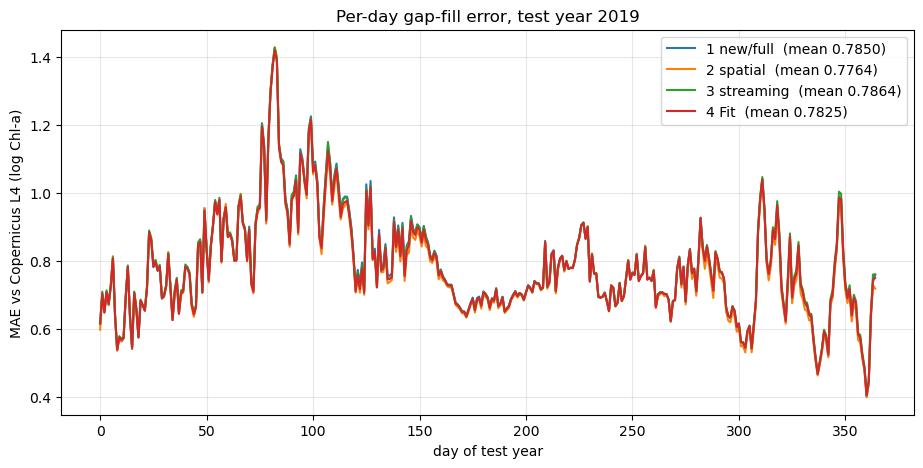

In [16]:
paths = {
    "1 new/full":   f"{MODEL_DIR}/run1_newcode_fullgrid.keras",
    "2 spatial":    f"{MODEL_DIR}/run2_spatial_40x56.keras",
    "3 streaming":  f"{MODEL_DIR}/run3_streaming.keras",
    "4 Fit":        f"{MODEL_DIR}/run4_fit.keras",
}
plt.figure(figsize=(11, 5))
for label, p in paths.items():
    if not os.path.exists(p):
        print("missing (run it first):", p); continue
    mae = per_day_mae(tf.keras.models.load_model(p))
    plt.plot(mae, label=f"{label}  (mean {np.nanmean(mae):.4f})")
plt.xlabel("day of test year"); plt.ylabel("MAE vs Copernicus L4 (log Chl-a)")
plt.title(f"Per-day gap-fill error, test year {TEST_YEAR}")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Notes / open items

- **Region vs GPU:** if runs 1/3/4 OOM on a whole full-grid frame at batch 1, set `SUBSET` to a smaller
  box (e.g. Arab Sea) and rerun everything on that region.
- **Run 1 vs Run 3** are both whole-domain and should match closely; that is the "new code == old code"
  check. **Run 2 vs the others** is the real question: does 40x56 patch training match whole-domain?
- The per-day eval uses training-mode channels. A stricter gap-fill eval (feed dense level-3 as
  `masked_CHL`, mark real clouds as gaps) mirrors the notebooks' `yearly_MAD_vs_cloud`; we can swap that
  in once the four models exist.
- Add a few visual gapfill panels (same region/extent) for a couple of common dates for a qualitative look.

In [17]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

y_mean, y_std = SHARED_STATS['CHL'][0], SHARED_STATS['CHL'][1]
m_mean, m_std = SHARED_STATS['masked_CHL'][0], SHARED_STATS['masked_CHL'][1]

def gapfill_X(when):
    """Gapfill-mode input for a date or a whole year: feed dense observed level-3 as masked_CHL
    and mark the real clouds (not the training fake clouds) as the pixels to fill."""
    sub = ds_std_test.sel(time=when)
    chans = {v: np.nan_to_num(sub[v].values, nan=0.0) for v in X_VARS}
    with np.errstate(divide='ignore', invalid='ignore'):
        obs = np.log(orig_full['CHL_cmes-level3'].sel(time=when).values)
    obs_std = np.nan_to_num((obs - m_mean) / m_std, nan=0.0, posinf=0.0, neginf=0.0)
    ofake, oreal = chans['fake_cloud_flag'].copy(), chans['real_cloud_flag'].copy()
    chans['masked_CHL']      = obs_std
    chans['fake_cloud_flag'] = oreal
    chans['real_cloud_flag'] = np.zeros_like(oreal)
    chans['valid_CHL_flag']  = np.where(ofake == 1, 1.0, chans['valid_CHL_flag'])
    return np.stack([chans[v] for v in X_VARS], axis=-1).astype(np.float32)


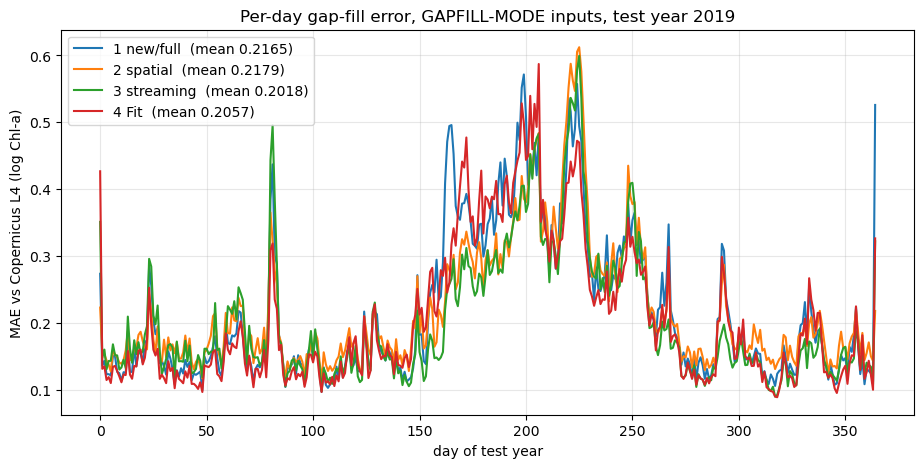

In [18]:
def per_day_mae_gapfill(model):
    X = gapfill_X(str(TEST_YEAR))                          # (days, lat, lon, C)
    pred = model.predict(X, batch_size=2, verbose=0)[..., 0] * y_std + y_mean
    with np.errstate(divide='ignore', invalid='ignore'):
        gap = np.log(orig_full['CHL_cmes-gapfree'].sel(time=str(TEST_YEAR)).values)
    lvl3 = orig_full['CHL_cmes-level3'].sel(time=str(TEST_YEAR)).values
    pred = np.where(~np.isnan(lvl3), np.nan, pred)         # score only the real-gap pixels
    return [compute_mae(t, p) for t, p in zip(gap, pred)]

plt.figure(figsize=(11, 5))
for label, p in paths.items():
    if not os.path.exists(p):
        print("missing:", p); continue
    mae = per_day_mae_gapfill(tf.keras.models.load_model(p))
    plt.plot(mae, label=f"{label}  (mean {np.nanmean(mae):.4f})")
plt.xlabel("day of test year"); plt.ylabel("MAE vs Copernicus L4 (log Chl-a)")
plt.title(f"Per-day gap-fill error, GAPFILL-MODE inputs, test year {TEST_YEAR}")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()


In [20]:
def gapfill_panels(dates):
    models = {label: tf.keras.models.load_model(p) for label, p in paths.items() if os.path.exists(p)}
    extent = [float(orig_full.lon.min()), float(orig_full.lon.max()),
              float(orig_full.lat.min()), float(orig_full.lat.max())]
    ncol = 1 + len(models)
    fig, axes = plt.subplots(len(dates), ncol, figsize=(2.8*ncol, 2.3*len(dates)),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = np.atleast_2d(axes)
    for r, date in enumerate(dates):
        date = pd.to_datetime(date)
        with np.errstate(divide='ignore', invalid='ignore'):
            truth = np.log(orig_full['CHL_cmes-gapfree'].sel(time=date).values)
        vmin, vmax = np.nanmin(truth), np.nanmax(truth)
        X = gapfill_X(date)[np.newaxis, ...]
        cols = [("Copernicus L4", truth)]
        for name, m in models.items():
            pr = m.predict(X, verbose=0)[0, :, :, 0] * y_std + y_mean
            cols.append((name, np.where(np.isnan(truth), np.nan, pr)))
        for c, (ttl, arr) in enumerate(cols):
            ax = axes[r, c]
            ax.imshow(arr, vmin=vmin, vmax=vmax, extent=extent, origin='upper',
                      transform=ccrs.PlateCarree(), interpolation='nearest')
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
            if r == 0:
                ax.set_title(ttl, size=9)
        axes[r, 0].text(-0.10, 0.5, str(date.date()), transform=axes[r, 0].transAxes,
                        rotation=90, va='center', ha='right', size=7)
    fig.subplots_adjust(wspace=0.04, hspace=0.06)
    plt.show()


dates: ['2019-01-01', '2019-01-20', '2019-02-08', '2019-02-27', '2019-03-18', '2019-04-06', '2019-04-25', '2019-05-15', '2019-06-03', '2019-06-22', '2019-07-11', '2019-07-30', '2019-08-18', '2019-09-07', '2019-09-26', '2019-10-15', '2019-11-03', '2019-11-22', '2019-12-11', '2019-12-31']


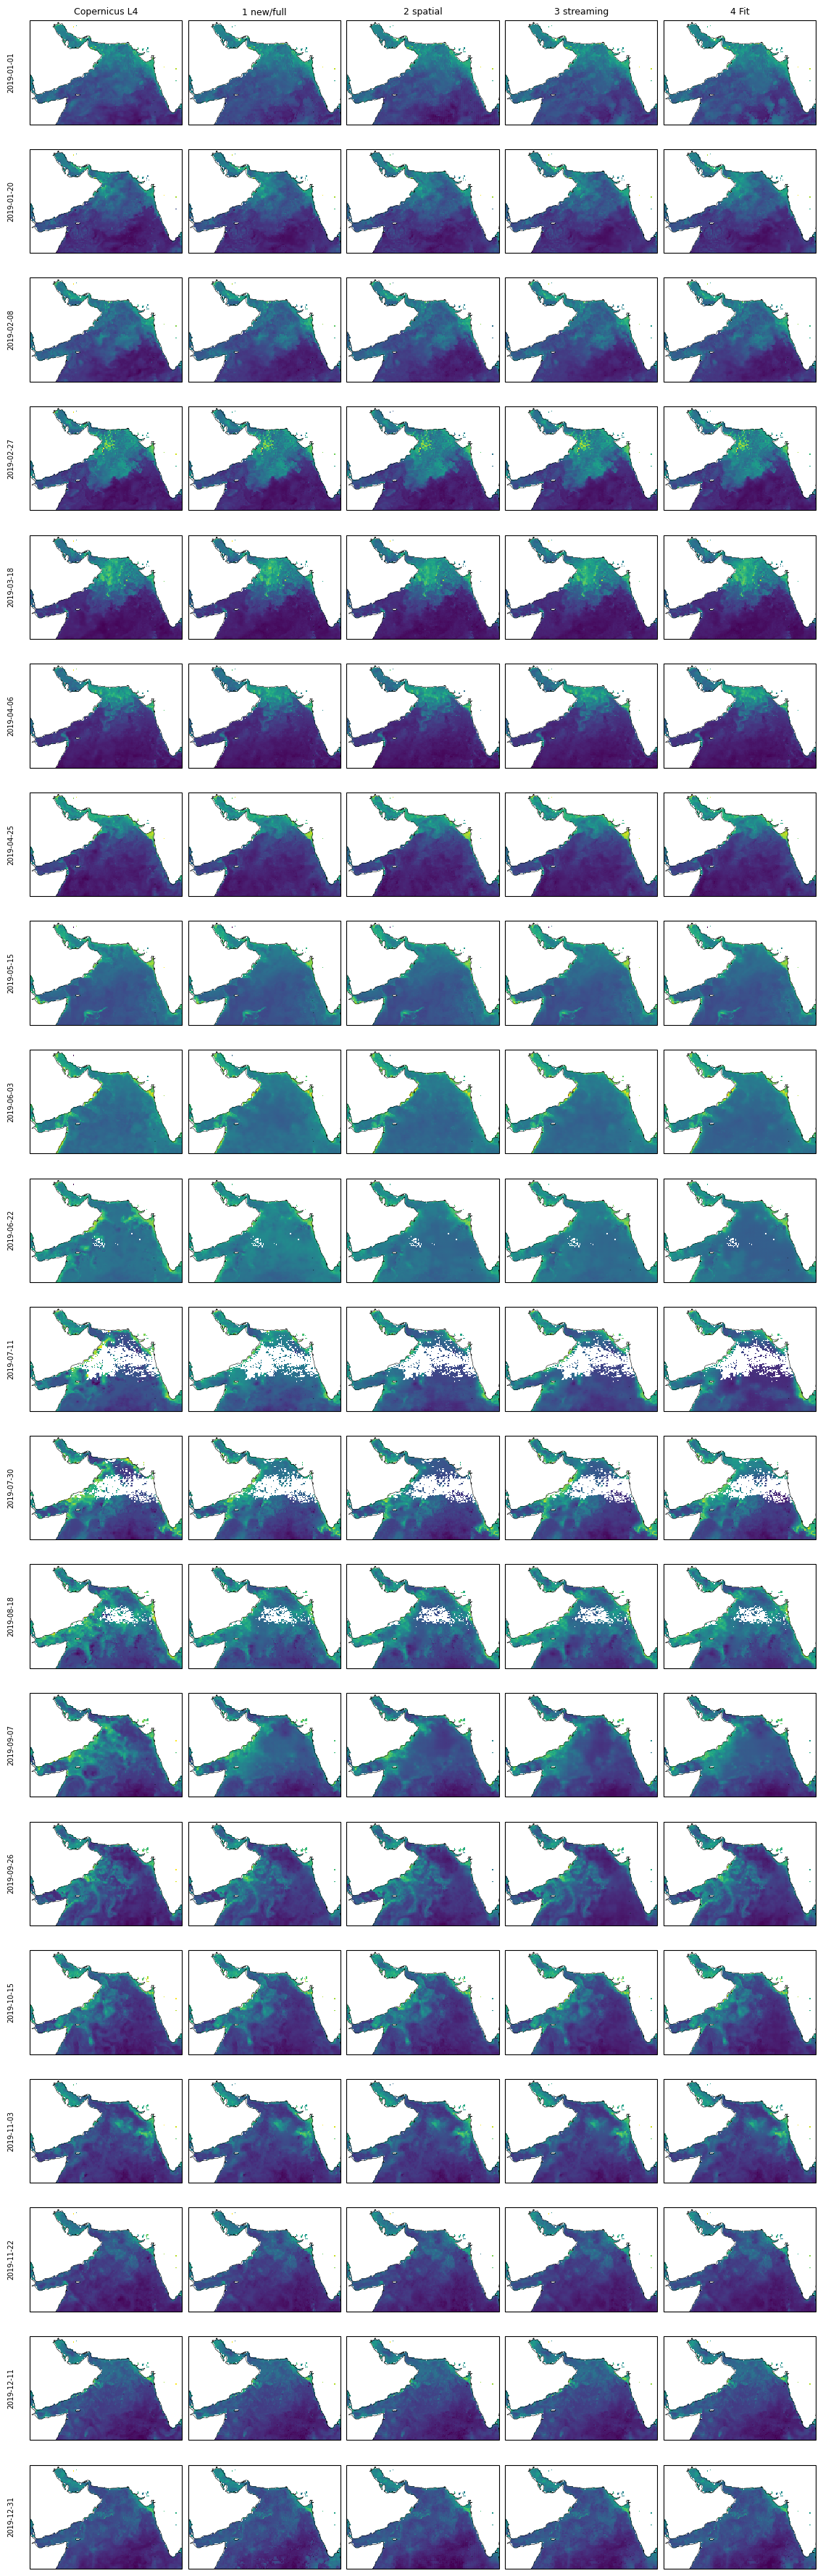

In [21]:
_days = ds_std_test.time.values
_idx  = np.linspace(0, len(_days) - 1, 20).astype(int)   # 20 evenly spaced across the year
DATES_20 = pd.to_datetime(_days[_idx])
print("dates:", [str(d.date()) for d in DATES_20])

gapfill_panels(DATES_20)


## Multi-seed m1 vs m3 comparison (subprocess automation)

Trains **m1** (whole-domain, rechunked) and **m3** (whole-domain, original) at several seeds, each
in its own subprocess so the GPU context resets between runs (no memory/cuDNN carryover). A matched
seed gives m1 and m3 the same init and shuffle order, so the eval difference isolates the
rechunked-vs-original data effect; the spread across seeds is the run-to-run noise floor.

Run the three cells below in order. The eval cell needs `per_day_mae_gapfill` (from the gapfill
section) already defined, and reports the gapfill-mode error only.

In [ ]:
import base64
_src = base64.b64decode(
    "aW1wb3J0IG9zLCBhcmdwYXJzZSwgcGlja2xlCm9zLmVudmlyb24ucG9wKCJURl9DVUROTl9ERVRFUk1JTklTVElDIiwgTm9uZSkKb3MuZW52aXJvbi5wb3AoIlRGX0NVRE5OX1VTRV9BVVRPVFVORSIsIE5vbmUpCm9zLmVudmlyb25bIlRGX0ZPUkNFX0dQVV9BTExPV19HUk9XVEgiXSA9ICJ0cnVlIgpvcy5lbnZpcm9uWyJURl9DUFBfTUlOX0xPR19MRVZFTCJdID0gIjIiCgppbXBvcnQgbnVtcHkgYXMgbnAsIHhhcnJheSBhcyB4ciwgdGVuc29yZmxvdyBhcyB0Zgpmcm9tIHRlbnNvcmZsb3cua2VyYXMgaW1wb3J0IElucHV0LCBsYXllcnMKZnJvbSB0ZW5zb3JmbG93LmtlcmFzLmNhbGxiYWNrcyBpbXBvcnQgRWFybHlTdG9wcGluZwpmcm9tIHhiYXRjaGVyIGltcG9ydCBCYXRjaEdlbmVyYXRvcgppbXBvcnQgbWluZHRoZWdhcCBhcyBtdGcKCmRlZiBVTmV0KGlucHV0X3NoYXBlKToKICAgIGlucHV0cyA9IElucHV0KHNoYXBlPWlucHV0X3NoYXBlKTsgeCA9IGlucHV0cwogICAgZmlsdGVycyA9IFs2NCwgMTI4LCAyNTZdOyBlYyA9IFtdCiAgICBmb3IgZiBpbiBmaWx0ZXJzOgogICAgICAgIGVjLmFwcGVuZCh4KQogICAgICAgIHggPSBsYXllcnMuQ29udjJEKGYsICgzLCAzKSwgcGFkZGluZz0ic2FtZSIsIGFjdGl2YXRpb249InJlbHUiKSh4KQogICAgICAgIHggPSBsYXllcnMuQ29udjJEKGYsICgzLCAzKSwgcGFkZGluZz0ic2FtZSIsIGFjdGl2YXRpb249InJlbHUiKSh4KQogICAgICAgIHggPSBsYXllcnMuTWF4UG9vbGluZzJEKCkoeCk7IHggPSBsYXllcnMuQmF0Y2hOb3JtYWxpemF0aW9uKCkoeCkKICAgIGZvciBmLCBlIGluIHppcChmaWx0ZXJzWzotMV1bOjotMV0sIGVjWzo6LTFdWzotMV0pOgogICAgICAgIHggPSBsYXllcnMuQ29udjJEVHJhbnNwb3NlKGYsIDMsIDIsIHBhZGRpbmc9InNhbWUiKSh4KQogICAgICAgIHggPSBsYXllcnMuY29uY2F0ZW5hdGUoW3gsIGVdKQogICAgICAgIHggPSBsYXllcnMuQ29udjJEKGYsICgzLCAzKSwgcGFkZGluZz0ic2FtZSIsIGFjdGl2YXRpb249InJlbHUiKSh4KQogICAgICAgIHggPSBsYXllcnMuQ29udjJEKGYsICgzLCAzKSwgcGFkZGluZz0ic2FtZSIsIGFjdGl2YXRpb249InJlbHUiKSh4KQogICAgICAgIHggPSBsYXllcnMuQmF0Y2hOb3JtYWxpemF0aW9uKCkoeCkKICAgIHggPSBsYXllcnMuQ29udjJEVHJhbnNwb3NlKGYsIDMsIDIsIHBhZGRpbmc9InNhbWUiKSh4KQogICAgeCA9IGxheWVycy5jb25jYXRlbmF0ZShbeCwgZWNbMF1dKQogICAgeCA9IGxheWVycy5Db252MkQoZiwgKDMsIDMpLCBwYWRkaW5nPSJzYW1lIiwgYWN0aXZhdGlvbj0icmVsdSIpKHgpCiAgICBvdXQgPSBsYXllcnMuQ29udjJEKDEsICgzLCAzKSwgcGFkZGluZz0ic2FtZSIsIGFjdGl2YXRpb249ImxpbmVhciIpKHgpCiAgICBtID0gdGYua2VyYXMuTW9kZWwoaW5wdXRzLCBvdXQsIG5hbWU9IlUtbmV0IikKICAgIG0uY29tcGlsZShvcHRpbWl6ZXI9ImFkYW0iLCBsb3NzPSJtc2UiLCBtZXRyaWNzPVsibWFlIl0pOyByZXR1cm4gbQoKZGVmIG9wZW5fcmVnaW9uKHBhdGgsIGMpOgogICAgZHMgPSB4ci5vcGVuX3phcnIocGF0aCwgY2h1bmtzPXt9KQogICAgaWYgY1siU1VCU0VUIl0gaXMgbm90IE5vbmU6IGRzID0gZHMuc2VsKCoqY1siU1VCU0VUIl0pCiAgICBkcyA9IG10Zy5jcm9wX3RvX211bHRpcGxlKGRzLCBtdWx0aXBsZT04KQogICAgdHksIHRyLCB2ciwgdGUgPSBjWyJ0cmFpbl95ZWFyIl0sIGNbInRyYWluX3JhbmdlIl0sIGNbInZhbF9yYW5nZSJdLCBjWyJ0ZXN0X3JhbmdlIl0KICAgIHJldHVybiBkcy5zZWwodGltZT1zbGljZShmInt0eX0tMDEtMDEiLCBmInt0eSt0cit2cit0ZX0tMDEtMDEiKSkKCmFwID0gYXJncGFyc2UuQXJndW1lbnRQYXJzZXIoKQphcC5hZGRfYXJndW1lbnQoIi0tc2VlZCIsIHR5cGU9aW50LCByZXF1aXJlZD1UcnVlKQphcC5hZGRfYXJndW1lbnQoIi0tcnVuIiwgdHlwZT1pbnQsIHJlcXVpcmVkPVRydWUsIGNob2ljZXM9WzEsIDNdKQphcC5hZGRfYXJndW1lbnQoIi0tY29uZmlnIiwgZGVmYXVsdD0ibW9kZWxzL2NvbXBhcmUvcnVuX2NvbmZpZy5wa2wiKQphID0gYXAucGFyc2VfYXJncygpCmMgPSBwaWNrbGUubG9hZChvcGVuKGEuY29uZmlnLCAicmIiKSkKCmZvciBnIGluIHRmLmNvbmZpZy5saXN0X3BoeXNpY2FsX2RldmljZXMoIkdQVSIpOgogICAgdGYuY29uZmlnLmV4cGVyaW1lbnRhbC5zZXRfbWVtb3J5X2dyb3d0aChnLCBUcnVlKQp0Zi5rZXJhcy51dGlscy5zZXRfcmFuZG9tX3NlZWQoYS5zZWVkKQoKc291cmNlID0gY1siUkVDSFVOS0VEIl0gaWYgYS5ydW4gPT0gMSBlbHNlIGNbIk9SSUdJTkFMIl0KZHMgPSBvcGVuX3JlZ2lvbihzb3VyY2UsIGMpCnR5LCB0ciwgdnIgPSBjWyJ0cmFpbl95ZWFyIl0sIGNbInRyYWluX3JhbmdlIl0sIGNbInZhbF9yYW5nZSJdCmxhdCwgbG9uID0gZHMuc2l6ZXNbImxhdCJdLCBkcy5zaXplc1sibG9uIl0KZHNfc3RkLCBfID0gbXRnLmJ1aWxkX3N0YW5kYXJkaXplZF9sYXp5KGRzLCBjWyJmZWF0dXJlcyJdLCB0eSwgdHIsIHN0YW5kYXJkaXplX2NobD1UcnVlLAogICAgc3RhdHM9Y1siU0hBUkVEX1NUQVRTIl0sIG91dHB1dF9jaHVua3M9eyJ0aW1lIjogY1siREFZX0JBVENIIl0sICJsYXQiOiBsYXQsICJsb24iOiBsb259KQp4X3ZhcnMgPSBbdiBmb3IgdiBpbiBkc19zdGQuZGF0YV92YXJzIGlmIHYgIT0gIkNITCJdCmRpbXMgPSB7InRpbWUiOiBjWyJEQVlfQkFUQ0giXSwgImxhdCI6IGxhdCwgImxvbiI6IGxvbn07IG92ID0geyJ0aW1lIjogMCwgImxhdCI6IDAsICJsb24iOiAwfQpzaWcgPSAodGYuVGVuc29yU3BlYygobGF0LCBsb24sIGxlbih4X3ZhcnMpKSwgdGYuZmxvYXQzMiksIHRmLlRlbnNvclNwZWMoKGxhdCwgbG9uLCAxKSwgdGYuZmxvYXQzMikpCgpkdHIgPSBkc19zdGQuc2VsKHRpbWU9c2xpY2UoZiJ7dHl9LTAxLTAxIiwgZiJ7dHkrdHJ9LTAxLTAxIikpLmxvYWQoKQpkdmEgPSBkc19zdGQuc2VsKHRpbWU9c2xpY2UoZiJ7dHkrdHJ9LTAxLTAxIiwgZiJ7dHkrdHIrdnJ9LTAxLTAxIikpLmxvYWQoKQpidHIgPSBCYXRjaEdlbmVyYXRvcihkdHIsIGlucHV0X2RpbXM9ZGltcywgaW5wdXRfb3ZlcmxhcD1vdikKYnZhID0gQmF0Y2hHZW5lcmF0b3IoZHZhLCBpbnB1dF9kaW1zPWRpbXMsIGlucHV0X292ZXJsYXA9b3YpCnRyZHMgPSB0Zi5kYXRhLkRhdGFzZXQuZnJvbV9nZW5lcmF0b3IobXRnLm1ha2VfdGZfZ2VuKGJ0ciwgeF92YXJzKSwgb3V0cHV0X3NpZ25hdHVyZT1zaWcKICAgICkuc2h1ZmZsZSg1MTIsIHNlZWQ9YS5zZWVkKS5iYXRjaCgxKS5yZXBlYXQoKS5wcmVmZXRjaCh0Zi5kYXRhLkFVVE9UVU5FKQp2YWRzID0gdGYuZGF0YS5EYXRhc2V0LmZyb21fZ2VuZXJhdG9yKG10Zy5tYWtlX3RmX2dlbihidmEsIHhfdmFycyksIG91dHB1dF9zaWduYXR1cmU9c2lnCiAgICApLmJhdGNoKDEpLnJlcGVhdCgpLnByZWZldGNoKHRmLmRhdGEuQVVUT1RVTkUpCm1vZGVsID0gVU5ldCgoTm9uZSwgTm9uZSwgbGVuKHhfdmFycykpKQptb2RlbC5maXQodHJkcywgZXBvY2hzPTUwLCBzdGVwc19wZXJfZXBvY2g9bGVuKGJ0cikgKiBjWyJEQVlfQkFUQ0giXSwKICAgICAgICAgIHZhbGlkYXRpb25fZGF0YT12YWRzLCB2YWxpZGF0aW9uX3N0ZXBzPWxlbihidmEpICogY1siREFZX0JBVENIIl0sCiAgICAgICAgICBjYWxsYmFja3M9W0Vhcmx5U3RvcHBpbmcocGF0aWVuY2U9MTAsIHJlc3RvcmVfYmVzdF93ZWlnaHRzPVRydWUpXSwgdmVyYm9zZT0yKQpvdXQgPSBmJ3tjWyJNT0RFTF9ESVIiXX0vcnVue2EucnVufV9zZWVke2Euc2VlZH0ua2VyYXMnCm1vZGVsLnNhdmUob3V0KTsgcHJpbnQoIlNBVkVEIiwgb3V0KQo="
).decode()
with open("train_one.py", "w") as f:
    f.write(_src)
print("wrote train_one.py")

In [ ]:
import sys, os, pickle, subprocess

cfg = dict(SUBSET=SUBSET, train_year=train_year, train_range=train_range, val_range=val_range,
           test_range=test_range, features=features, DAY_BATCH=DAY_BATCH,
           RECHUNKED=RECHUNKED, ORIGINAL=ORIGINAL, MODEL_DIR=MODEL_DIR, SHARED_STATS=SHARED_STATS)
os.makedirs(MODEL_DIR, exist_ok=True)
pickle.dump(cfg, open(f"{MODEL_DIR}/run_config.pkl", "wb"))

SEEDS = [0, 1, 2, 3, 4]
for s in SEEDS:
    for run in (1, 3):
        out = f"{MODEL_DIR}/run{run}_seed{s}.keras"
        if os.path.exists(out):
            print("skip (exists):", out); continue
        print(f"\n===== training run{run} seed{s} =====", flush=True)
        rc = subprocess.run([sys.executable, "train_one.py", "--seed", str(s), "--run", str(run)]).returncode
        print(f"----- run{run} seed{s} exited {rc} -----")
print("\nall done")

In [ ]:
SEEDS = [0, 1, 2, 3, 4]
res = {}
for s in SEEDS:
    for run, tag in [("run1", "m1"), ("run3", "m3")]:
        p = f"{MODEL_DIR}/{run}_seed{s}.keras"
        res[(tag, s)] = (np.nanmean(per_day_mae_gapfill(tf.keras.models.load_model(p)))
                         if os.path.exists(p) else np.nan)

print(f"{'seed':>4} {'m1':>8} {'m3':>8} {'m1-m3':>9} {'%':>7}")
diffs = []
for s in SEEDS:
    v1, v3 = res[("m1", s)], res[("m3", s)]; d = v1 - v3; diffs.append(d)
    print(f"{s:>4} {v1:8.4f} {v3:8.4f} {d:+9.4f} {100*d/v3:+6.1f}%")

m1v = np.array([res[("m1", s)] for s in SEEDS]); m3v = np.array([res[("m3", s)] for s in SEEDS])
print(f"\nm1 across seeds: mean {np.nanmean(m1v):.4f}, std {np.nanstd(m1v):.4f}")
print(f"m3 across seeds: mean {np.nanmean(m3v):.4f}, std {np.nanstd(m3v):.4f}")
print(f"mean |m1-m3| at matched seed: {np.nanmean(np.abs(diffs)):.4f} "
      f"({100 * np.nanmean(np.abs(diffs)) / np.nanmean(m3v):.1f}%)")

### Direct data-source check (no training)

Rules out the rechunked zarr without training anything: builds the standardized **training** array
from `RECHUNKED` and from `ORIGINAL` over the same region/time with the same shared stats, then
compares them. If the NaN masks match and the max abs diff is ~0, the two files carry identical
training data, so any m1 vs m3 gap is pure seed noise, not the rechunking. If they differ, the
rechunking altered the values and that is the culprit.

In [ ]:
def std_train_array(path):
    ds = xr.open_zarr(path, chunks={})
    if SUBSET is not None: ds = ds.sel(**SUBSET)
    ds = mtg.crop_to_multiple(ds, multiple=8)
    ds = ds.sel(time=slice(f"{train_year}-01-01", f"{train_year+train_range}-01-01"))
    lat, lon = ds.sizes["lat"], ds.sizes["lon"]
    ds_std, _ = mtg.build_standardized_lazy(ds, features, train_year, train_range,
        standardize_chl=True, stats=SHARED_STATS,
        output_chunks={"time": DAY_BATCH, "lat": lat, "lon": lon})
    xv = [v for v in ds_std.data_vars if v != "CHL"]
    X = np.stack([ds_std[v].values for v in xv], -1)
    y = ds_std["CHL"].values
    return X, y, xv

Xr, yr, vr_ = std_train_array(RECHUNKED)
Xo, yo, vo_ = std_train_array(ORIGINAL)
print("same feature vars:", vr_ == vo_)
print("rechunked vars:", vr_)
print("original  vars:", vo_)
print("same shape:", Xr.shape == Xo.shape, "->", Xr.shape, "vs", Xo.shape)
for nm, A, B in [("X", Xr, Xo), ("y (CHL)", yr, yo)]:
    if A.shape != B.shape:
        print(f"{nm}: SHAPE MISMATCH {A.shape} vs {B.shape}"); continue
    nan_match = np.array_equal(np.isnan(A), np.isnan(B))
    both = ~np.isnan(A) & ~np.isnan(B)
    maxdiff = float(np.max(np.abs(A[both] - B[both]))) if both.any() else 0.0
    print(f"{nm}: NaN masks identical = {nan_match},  max abs diff (both finite) = {maxdiff:.3e}")